In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

## Importamos los datos

In [100]:
df = pd.read_csv("../data/stars_data.csv")

## EDA (Exploratory Data Analysis)

El dataset con el que vamos a trabajar tiene las siguientes características:

+ Entradas: 240

+ Columnas: 6
    + 4 Variables Numéricas

    + 2 Variables Categóricas con carácter ordinal

+ No existen Missing Values

In [101]:
# Información elemental de nuestro dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     240 non-null    int64  
 1   L               240 non-null    float64
 2   R               240 non-null    float64
 3   A_M             240 non-null    float64
 4   Color           240 non-null    object 
 5   Spectral_Class  240 non-null    object 
dtypes: float64(3), int64(1), object(2)
memory usage: 11.4+ KB


In [102]:
# Comprobamos si hay valores nulos en alguna fila
df.isna().sum()

Temperature       0
L                 0
R                 0
A_M               0
Color             0
Spectral_Class    0
dtype: int64

In [103]:
# Descriptivos de las variables numéricas
df.describe()

,Temperature,L,R,A_M
count,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396
std,9552.425037,179432.244940,517.155763,10.532512
min,1939.000000,0.000080,0.008400,-11.920000
25%,3344.250000,0.000865,0.102750,-6.232500
50%,5776.000000,0.070500,0.762500,8.313000
75%,15055.500000,198050.000000,42.750000,13.697500
max,40000.000000,849420.000000,1948.500000,20.060000


In [104]:
# Exploramos las categorías de las variables categóricas
for col in df.select_dtypes('object'):
    print(df[col].unique())
    print()
    print(df[col].value_counts())
    print()

['Red' 'Blue White' 'White' 'Yellowish White' 'Blue white'
 'Pale yellow orange' 'Blue' 'Blue-white' 'Whitish' 'yellow-white'
 'Orange' 'White-Yellow' 'white' 'yellowish' 'Yellowish' 'Orange-Red'
 'Blue-White']

Color
Red                   112
Blue                   56
Blue-white             26
Blue White             10
yellow-white            8
White                   7
Blue white              4
white                   3
Yellowish White         3
Orange                  2
Whitish                 2
yellowish               2
Pale yellow orange      1
White-Yellow            1
Yellowish               1
Orange-Red              1
Blue-White              1
Name: count, dtype: int64

['M' 'B' 'A' 'F' 'O' 'K' 'G']

Spectral_Class
M    111
B     46
O     40
A     19
F     17
K      6
G      1
Name: count, dtype: int64



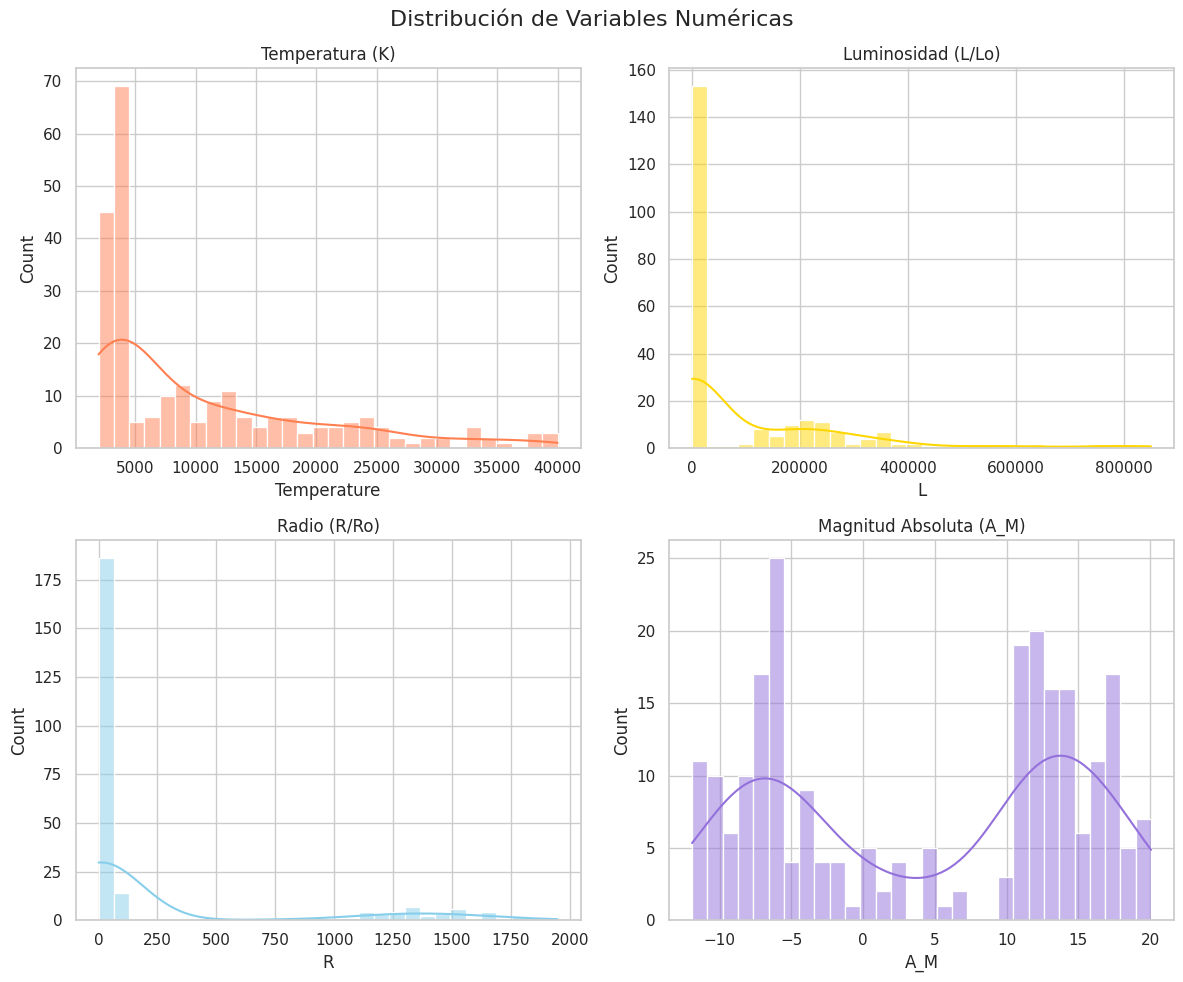

In [105]:
import seaborn as sns
sns.set_theme(style="whitegrid")

# Histogramas para ver la distribución de las variables numéricas
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Distribución de Variables Numéricas', fontsize=16)

sns.histplot(df['Temperature'], bins=30, kde=True, ax=axes[0, 0], color='coral')
axes[0, 0].set_title('Temperatura (K)')

sns.histplot(df['L'], bins=30, kde=True, ax=axes[0, 1], color='gold')
axes[0, 1].set_title('Luminosidad (L/Lo)')

sns.histplot(df['R'], bins=30, kde=True, ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title('Radio (R/Ro)')

sns.histplot(df['A_M'], bins=30, kde=True, ax=axes[1, 1], color='mediumpurple')
axes[1, 1].set_title('Magnitud Absoluta (A_M)')

plt.tight_layout()
plt.show()

Como podemos observar, hay ciertos datos muy frecuentes, y unos outliers muy claros. Esto nos da el insight de que será necesario hacer un escalado logarítmico para evitar este hecho y que los outliers no tengan tanto peso.

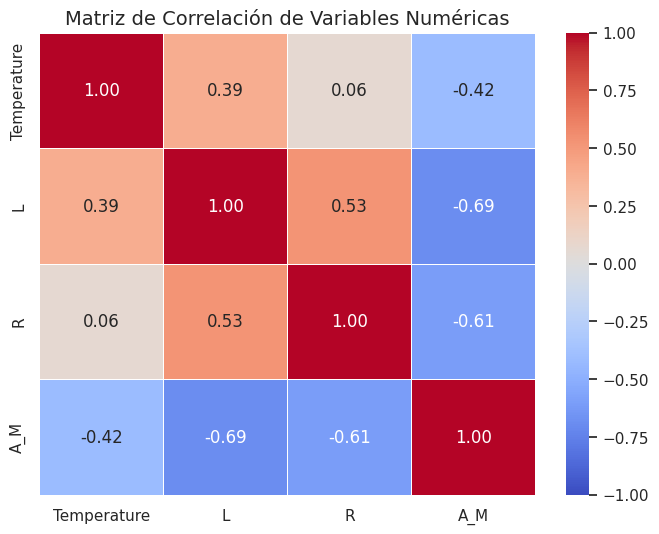

In [106]:
# Matriz de correlación para buscar relaciones lineales antes del PCA
plt.figure(figsize=(8, 6))

# Seleccionamos solo las columnas numéricas
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Variables Numéricas', fontsize=14)
plt.show()

Podemos observar correlaciones bastante importantes, tanto positivas como negativas. Esto es importante ya 
que a la hora de realizar el PCA y reducir dimensiones, la correlación entre features juega un papel crucial.

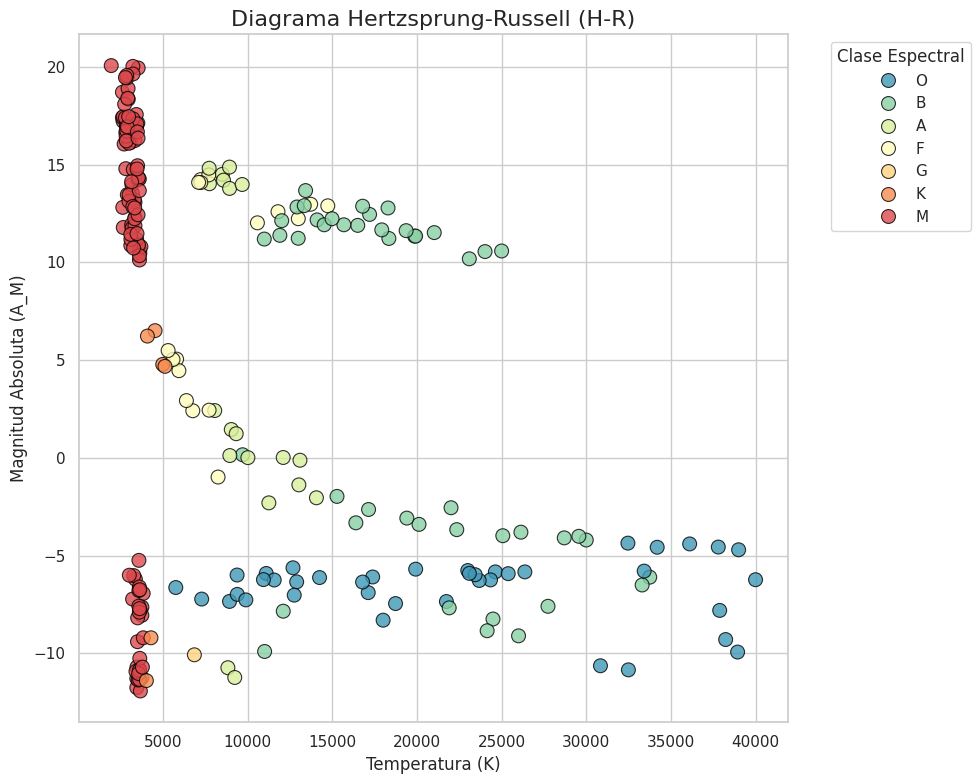

In [107]:
# Diagrama H-R: Temperatura vs Magnitud Absoluta
plt.figure(figsize=(10, 8))

# Ordenamos las clases espectrales para la leyenda
spectral_order = ['O', 'B', 'A', 'F', 'G', 'K', 'M']

sns.scatterplot(
    data=df, 
    x='Temperature', 
    y='A_M', 
    hue='Spectral_Class',
    hue_order=spectral_order,
    palette='Spectral_r',
    s=100, 
    alpha=0.8,
    edgecolor='black'
)

plt.title('Diagrama Hertzsprung-Russell (H-R)', fontsize=16)
plt.xlabel('Temperatura (K)', fontsize=12)
plt.ylabel('Magnitud Absoluta (A_M)', fontsize=12)
plt.legend(title='Clase Espectral', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Con este diagrama (Temperatura vs. Magnitud Absoluta) podemos observar que las estrellas del dataset presentan cierto agrupamiento natural inherente a sus características físicas. Visualmente, se distinguen clústeres algo definidos que separan a las estrellas en grupos diferenciados (como la secuencia principal, enanas o gigantes), coincidiendo con las clasificaciones astronómicas. 

Nuestros algoritmos de clustering deberán ser capaces de recuperar matemáticamente a partir de los componentes principales (PCA).

## Preprocessing

A continuación, vamos a realizar el preprocesado que va a consistir esencialmente en:

+ Convertir a variables ordinales las variables `color` y `spectral_class`.

+ Aplicar `StandardScaler` para poder usar PCA en el siguiente apartado.

In [108]:
# Función para limpiar los colores
def process_color(X: pd.DataFrame) -> pd.DataFrame:
    # Declaramos el diccionario de sustitución (también se podría hacer con un condicional)
    color_mapping = {
    'Red': 'Red',
    'Orange-Red': 'Orange', # Discutible Orange o Red
    'Orange': 'Orange',
    'Pale yellow orange': 'Orange', # Discutible si Yellow u Orange
    'Yellowish': 'Yellow',
    'yellowish': 'Yellow',
    'yellow-white': 'Yellow-White',
    'Yellowish White': 'Yellow-White',
    'White-Yellow': 'Yellow-White',
    'White': 'White',
    'white': 'White',
    'Whitish': 'White',
    'Blue White': 'Blue-White',
    'Blue white': 'Blue-White',
    'Blue-white': 'Blue-White',
    'Blue-White': 'Blue-White',
    'Blue': 'Blue'
    }

    # Hacemos una copia del Dataset
    X_out = X.copy()

    # Sustituimos el color usando el método replace
    X_out["Color"] = X_out["Color"].replace(color_mapping)

    return X_out

# Limpiamos la columna color porque tiene 17 categorías y muchas son redundantes
color_transformer = FunctionTransformer(process_color)


In [109]:
# Creamos dos listas con el ORDEN DESEADO.
color_order = ['Blue', 'Blue-White', 'White', 'Yellow-White', 'Yellow', 'Orange', 'Red']
spectral_class_order = ["O", "B", "A", "F", "G", "K", "M"] # O (frío) y M (caliente)

# Definimos las columnas sobre las que queremos aplicar el encoder
cat_cols = ['Color', 'Spectral_Class']

# Definimos preprocesado y escalado para las variables numéricas (muy importante el escalado logarítmico)
# Excluimos A_M ya que tiene valores negativos que pueden causar conflicto con el escalado logarítmico
num_cols = ['Temperature', 'L', 'R']

# Creamos el encoder que aplicaremos en la siguiente sección usando ColumnTransformer
# (Usamos OrdinalEncoder ya que el orden es importante)
encoder = ColumnTransformer(
    transformers=[
        ('num_encoder', FunctionTransformer(np.log1p), num_cols),
        ('cat_encoder', OrdinalEncoder(categories=[color_order, spectral_class_order]), cat_cols)
    ],
    remainder='passthrough' # Para seguir manteniendo las numéricas
)

## PCA

En esta sección, vamos a reducir la dimensionalidad de nuestro a dataset a dos dimensiones antes de aplicar algoritmos de clustering.

### Creación de Pipeline
Este pipeline es con el PCA sin especificar que sólo queremos las dos primeras componentes, ya que queremos obtener los gráficos de varianza explicada y sedimentación antes de sacar únicamente las dos componentes.

In [110]:
initial_pipe = Pipeline([
    ("color", color_transformer),
    ("encoder", encoder),
    ("scaler", StandardScaler()),
    ("pca", PCA())
])

### Creación Conjunto Atributos

In [111]:
X = df.copy()

### Procesamiento del Pipeline

In [112]:
# Ajustar y transformar
X_reduced = initial_pipe.fit_transform(X)
pca = initial_pipe.named_steps['pca']

# Varianza explicada y acumulada
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Eigenvalues
eigenvalues = pca.explained_variance_

En esta gráfica podemos ver la varianza explicada por cada componente. Podemos observar que las que más explican son las dos primeras, el resto de componentes son residuales. Por lo que lo ideal será quedarse con las dos más relevantes (que es justo lo que pide el enunciado).

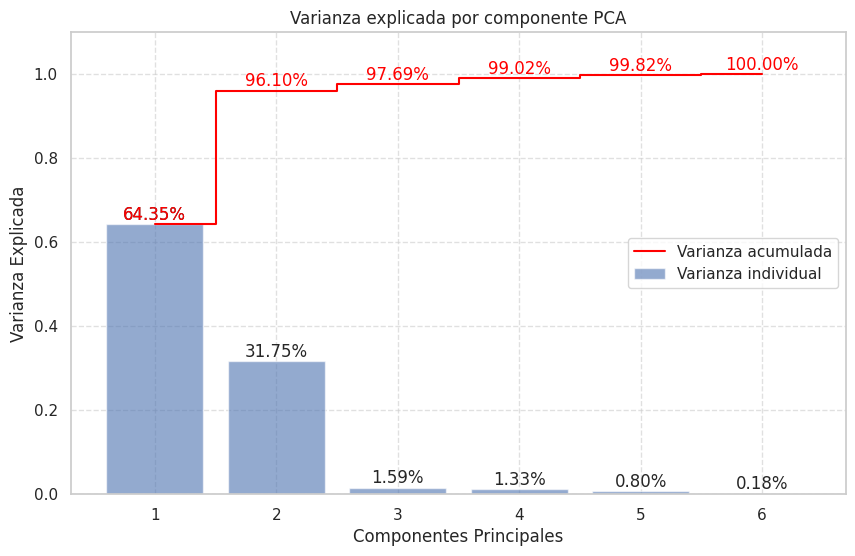

In [113]:
# Plot de Varianza Explicada y Acumulada
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.6, label='Varianza individual')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', label='Varianza acumulada', color='red')

# Añadir valores exactos
for i, (ev, cv) in enumerate(zip(explained_variance, cumulative_variance)):
    plt.text(i + 1, ev + 0.01, f"{ev:.2%}", ha='center')
    plt.text(i + 1, cv + 0.01, f"{cv:.2%}", ha='center', color='red')

plt.xlabel('Componentes Principales')
plt.ylabel('Varianza Explicada')
plt.title('Varianza explicada por componente PCA')
plt.legend(loc='best')
plt.ylim(0, 1.1)
plt.grid(True, linestyle='--', alpha=0.6)

En el siguiente gráfico de sedimentación podemos ver que el "codo" (la zona en la que la gráfica se aplana) es en el tercer componente, por lo que lo ideal tras hacer el PCA es quedarse con dos componentes, ya que el resto de componentes apenas aportan información relevante (justo lo que se pide en este ejercicio).

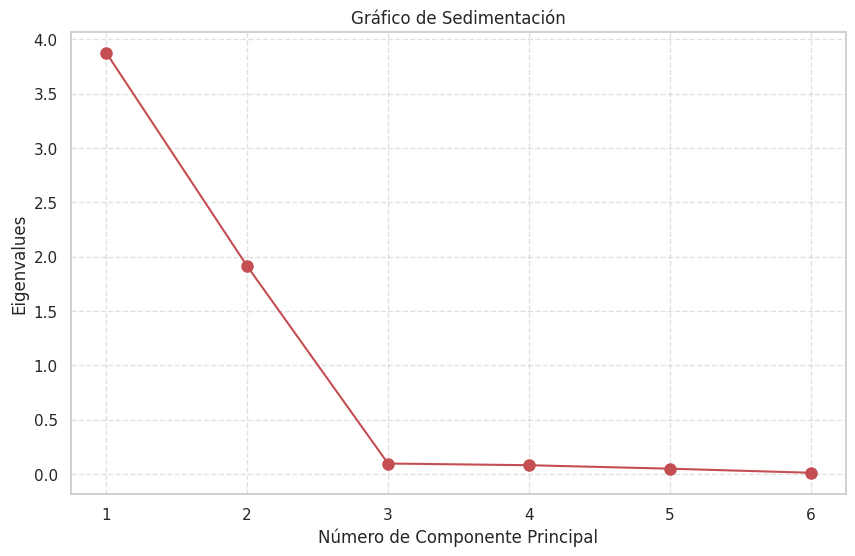

In [114]:
# Gráfico de sedimentación
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, marker='o', linestyle='-', color='r', markersize=8)

plt.title('Gráfico de Sedimentación')
plt.xlabel('Número de Componente Principal')
plt.ylabel('Eigenvalues')
plt.xticks(range(1, len(eigenvalues) + 1))
plt.grid(True, linestyle='--', alpha=0.6)

Pipeline definitivo especificando que sólo queremos 2 componentes.

In [115]:
final_pipe = Pipeline([
    ("color", color_transformer),
    ("encoder", encoder),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2))
])

X_reduced = final_pipe.fit_transform(X)

Pintamos un scatter plot inicial para ver la distribución tras hacer el PCA con dos componentes. Podemos ver ciertas agrupaciones claras, aunque algunas que no tanto. Ahora será trabajo de los diferentes algoritmos de clustering el agruparlos correctamente.

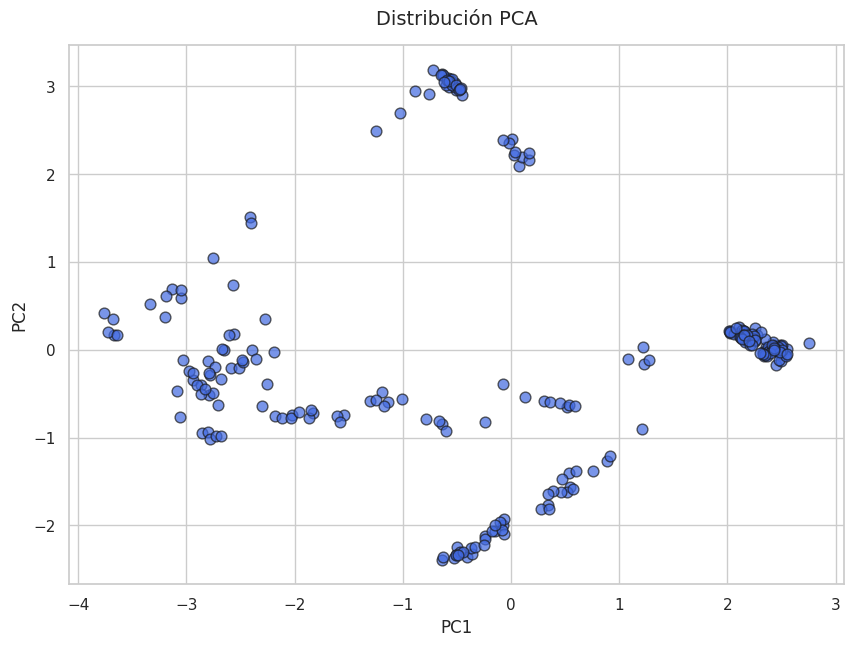

In [ ]:
plt.figure(figsize=(10, 7))

plt.scatter(X_reduced[:, 0], X_reduced[:, 1], 
            alpha=0.7,
            edgecolors='k',
            s=60,
            color='royalblue')

plt.title('Distribución PCA', fontsize=14, pad=15)
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.show()